In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

In [52]:
df = pd.read_csv("C:/Users/rotim/Downloads/Electric_Production.csv")

In [53]:
df.head(20)

# We begin by reviewing the first 20 rows of the data set in order to understand the data types recorded, the number and variety of features, and the format of the data set.
# This data set has two variables, which are 'Date' and 'IPG2211A2N'. Because the title of the csv file we loaded and defined as our data frame is 'Electric Production', 'IPG2211A2N' likely relates to an energy production ID or marker of some kind.
# Within the Date column, the first day of each successive month is recorded, beginning with January 1st of 1985.
# Within the column labeled 'IPG2211A2N', numberic values, likely energy production readings, are recorded.
# Because energy production is recorded at regular intervals of time, we can deem this to be a time series data set.
# Within the time series data set, Date would be our only feature, and 'IPG2211A2N' (energy production) would be our target variable.

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151
5,6/1/1985,58.0904
6,7/1/1985,62.6202
7,8/1/1985,63.2485
8,9/1/1985,60.5846
9,10/1/1985,56.3154


In [54]:
# 1 -- EXPLORATORY DATA ANALYSIS

In [55]:
df.describe()

# We use df.describe() to summarize the statistic details of the columns with numeric data points.
# 'IPG2211A2N'(energy production), our target variable, is the only column with numeric values.
# From the summary statistics, we can ascertain that there are 397 data points recorded, with values ranging from 55.3 to 129.4.
# The mean value of the data points is 88.8. 

,IPG2211A2N
count,397.000000
mean,88.847218
std,15.387834
min,55.315100
25%,77.105200
50%,89.779500
75%,100.524400
max,129.404800


In [56]:
df.info()

# We use df.info() in order to review the general details pertaining to the data frame.
# From the information generated, we can establish that the data frame has no null or missing values since there are 397 entries and all the columns have 397 non-null entries.
# Furthermore, the Date column has data recorded as objects, whereas 'IPG2211A2N' (energy production) has numberic data recorded as decimal values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DATE        397 non-null    object 
 1   IPG2211A2N  397 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.3+ KB


In [57]:
df['IPG2211A2N'].median()

# Because the median was not printed as part of the summary statistics, we use df['IPG2211A2N'].median() to generate the median value of the energy production data points.
# The median value for energy production is 89.78.
# We cannot generate the median value for the Date column as the recorded data is not numeric.

89.7795

In [58]:
df['DATE'] = pd.to_datetime(df['DATE'])

# Because the data within the Date column is recorded as objects, we will convert the data to the datetime format for analysis of the time series. 

In [59]:
df.set_index('DATE',inplace=True)

# For the purpose of visualizing the time series data, we will set Date as the index.

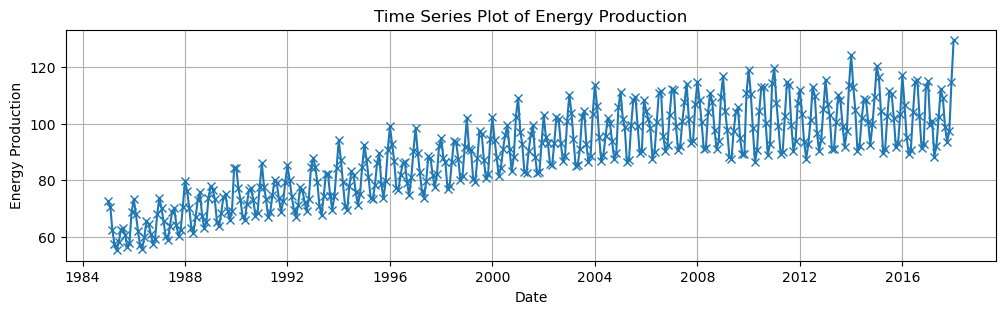

In [60]:
plt.figure(figsize=(12, 3))
plt.plot(df.index, df['IPG2211A2N'], marker='x')
plt.title('Time Series Plot of Energy Production')
plt.xlabel('Date')
plt.ylabel('Energy Production')
plt.grid(True)
plt.show()

# The time series plot of the data suggests that, from 1985 to 2018, energy production has steadily increased from about 60 units to over 120 units.
# However, when examined on a much narrower time horizon (or time frame), energy production tends to be volatile, with periodic high and low readings being observed each recorded calendar year.

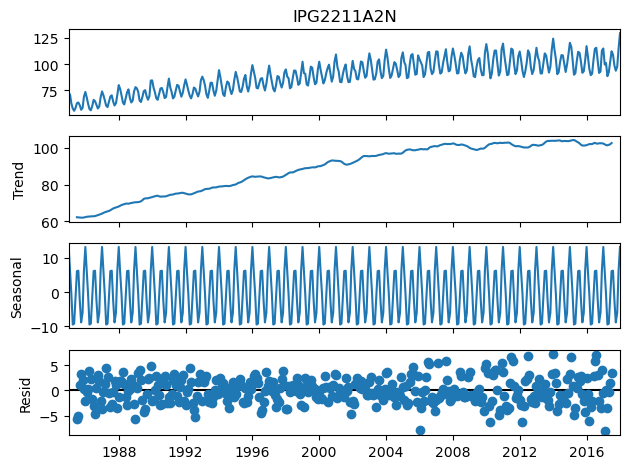

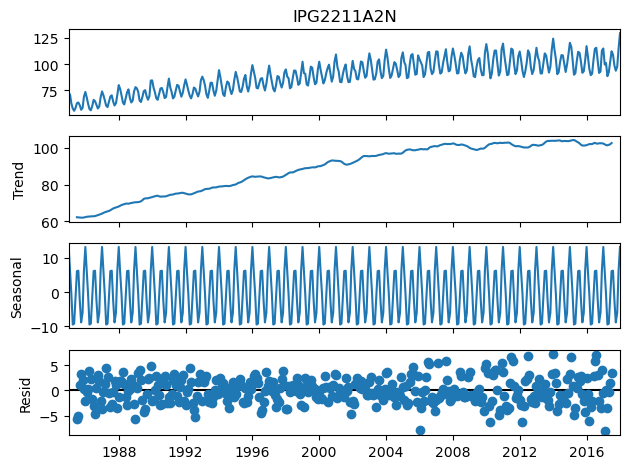

In [61]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df['IPG2211A2N'], model='additive', period=12)
decomp.plot()

# We apply decomposition to the time series data in order to separate the data into its trend, seasonal, and residual components.
# Trend relates to the long-term general direction of the data. The trend plot shows a gradual upward movement or growth, which plateaus and levels off around 2008.
# The seasonal component relates to the short-term cyclical patterns. The seasonal plot shows upward and downward fluctuations between 10 and -10 over the course of the years recorded. This implies strong seasonal cycles.
# The residual component relates to the noise and unpredictable patterns that are not tied to the trend or seasonal components. The residual plot shows points clustered around zero over the course of the years recorded. The points begin to scatter over a wider range from 2010 onward.

array([[<Axes: title={'center': 'IPG2211A2N'}>]], dtype=object)

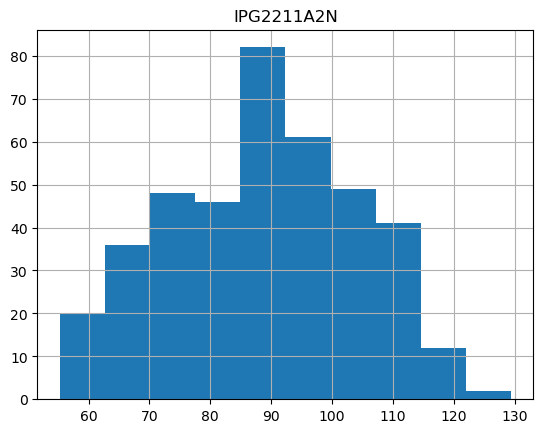

In [62]:
df.hist()

# We can generate a historgram plot for the time series data in order to understanding the general distribution of the energy production data points.
# The histogram plot we've created has energy production measured on the x-axis and the frequency (or count) of data points on the y-axis.
# Upon reviewing the histogram, we can determine that there is a normal distribution of energy production values within the data set.

In [63]:
corr_matrix = df.corr(method='pearson')
print(corr_matrix)

# We generate a Pearson correlation matrix and review the correlation coefficients between the features within the data frame.
# The only feature displayed within our correlation matrix is energy production.
# We will generate a new correlation matrix once we have engineered additional features within the data frame.

            IPG2211A2N
IPG2211A2N         1.0


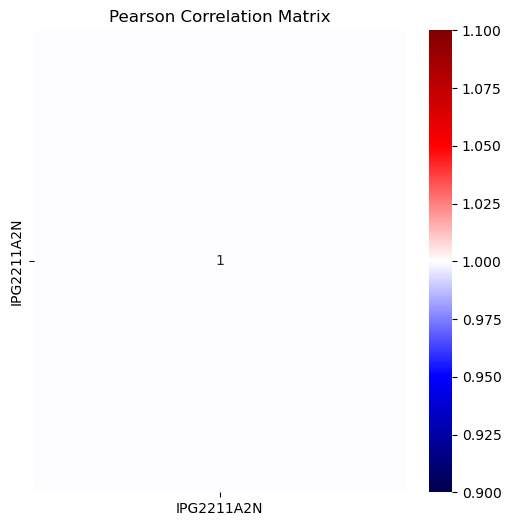

In [64]:
plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True, cmap='seismic')
plt.title('Pearson Correlation Matrix')
plt.show()

In [65]:
# 2 -- DATA PREPROCESSING & FEATURE ENGINEERING

In [66]:
df.isnull().sum()

# We double-check for missing values within the data set by using df.isnull().sum().
# The output value of '0' confirms that there are no missing values.

IPG2211A2N    0
dtype: int64

In [67]:
df.columns = df.columns.str.replace("IPG2211A2N", "Energy Production")
    
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Quarter'] = df.index.quarter
df['Day of Week'] = df.index.dayofweek 


# We perform feature engineering in order to add new features to the data frame.
# We first rename the 'IPG2211A2N' column to 'Energy Production' as this title is more relevant and easily understood.
# We also create features for the year, month, quarter, and day of the week for each date recorded in our time series index. This will enable us to review patterns within the data using smaller time frames.

In [68]:
df.head()

,Energy Production,Year,Month,Quarter,Day of Week
DATE,,,,,
1985-01-01,72.5052,1985,1,1,1
1985-02-01,70.6720,1985,2,1,4
1985-03-01,62.4502,1985,3,1,4
1985-04-01,57.4714,1985,4,2,0
1985-05-01,55.3151,1985,5,2,2


In [69]:
def seasons(Month):
    if Month in [1,2,12]:
        return "Winter"
    elif Month in [3,4,5]:
        return "Spring"
    elif Month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df['Season'] = df['Month'].apply(seasons)

# We engineer a 'Season' feature by creating lists for each season using the month values within the 'Month' column in order to define the seasons.

In [70]:
df.head()

,Energy Production,Year,Month,Quarter,Day of Week,Season
DATE,,,,,,
1985-01-01,72.5052,1985,1,1,1,Winter
1985-02-01,70.6720,1985,2,1,4,Winter
1985-03-01,62.4502,1985,3,1,4,Spring
1985-04-01,57.4714,1985,4,2,0,Spring
1985-05-01,55.3151,1985,5,2,2,Spring


In [71]:
from sklearn.preprocessing import LabelEncoder

encoder = {"Winter": 0, "Spring": 1, "Summer": 2, "Autumn": 2}
df['Season'] = df['Season'].map(encoder)

# To ensure that the 'Season' feature can be easily utilized by the machine learning algorithms that we will later employ, we encode the season labels.
# Winter will convert to '0', Spring will convert to '1', Summer will convert to '2', and Autumn will convert to '3'.

In [72]:
df.head()

,Energy Production,Year,Month,Quarter,Day of Week,Season
DATE,,,,,,
1985-01-01,72.5052,1985,1,1,1,0
1985-02-01,70.6720,1985,2,1,4,0
1985-03-01,62.4502,1985,3,1,4,1
1985-04-01,57.4714,1985,4,2,0,1
1985-05-01,55.3151,1985,5,2,2,1


In [73]:
df['1-Month Lag'] = df['Energy Production'].shift(1)
df['3-Month Lag'] = df['Energy Production'].shift(3)
df['6-Month Lag'] = df['Energy Production'].shift(12)

df['3-Month Rolling Mean'] = df['Energy Production'].rolling(window=3).mean()

# We create lag features for 1-month, 3-month, and 6-month lag time frames. They represent energy production values from prior months, for instance, 1 month prior or 3 months prior, and will be used for forecasting.
# We also create a rolling time frame feature to represent the 3-month moving average for energy production. This will help to better understand and detect quarterly patterns.

In [74]:
df.head()

,Energy Production,Year,Month,Quarter,Day of Week,Season,1-Month Lag,3-Month Lag,6-Month Lag,3-Month Rolling Mean
DATE,,,,,,,,,,
1985-01-01,72.5052,1985,1,1,1,0,NaN,NaN,NaN,NaN
1985-02-01,70.6720,1985,2,1,4,0,72.5052,NaN,NaN,NaN
1985-03-01,62.4502,1985,3,1,4,1,70.6720,NaN,NaN,68.542467
1985-04-01,57.4714,1985,4,2,0,1,62.4502,72.5052,NaN,63.531200
1985-05-01,55.3151,1985,5,2,2,1,57.4714,70.6720,NaN,58.412233


In [75]:
Q3_EP = df['Energy Production'].quantile(0.75)
Q1_EP = df['Energy Production'].quantile(0.25)
IQR = Q3_EP - Q1_EP


low_EP = Q1_EP - 1.5 * IQR
high_EP = Q3_EP + 1.5 * IQR


median_EP = df['Energy Production'].median()
df['Energy Production'] = df['Energy Production'].apply(lambda x: median_EP if x < low_EP or x > high_EP else x)


# To remove noisy data points and outliers, we calculate the first and third quartiles, in addition to the interquartile range, and convert any Energy Production outliers to the median of the data range.
# We multiply the interquartile range value by 1.5, add the product to the third quartile, and subtract the product from the first quartile in order to determine the lower and upper bounds for outliers.
# We then change any data point beyond the lower and upper bounds to the median of the Energy Production data range.

In [76]:
from scipy.stats import zscore

df['Z Score'] = zscore(df['Energy Production'])
Zscore_outliers = df[df['Z Score'].abs() > 3]
print(Zscore_outliers)

# We can also check for Energy Production outliers using the z-score function.
# Using the z-score function, we check for any data points that have a z-score with an absolute value greater than 3. Z-scores of -3 and +3 will serve as the lower and upper bounds for identifying outliers.

Empty DataFrame
Columns: [Energy Production, Year, Month, Quarter, Day of Week, Season, 1-Month Lag, 3-Month Lag, 6-Month Lag, 3-Month Rolling Mean, Z Score]
Index: []


In [77]:
df_cleaned = df.dropna()

df_cleaned.head()

# Because the creation of the lag and rolling time frame features resulted in null data points within the first several rows of the data frame, we use df.dropna() to remove the rows with null or missing values.

,Energy Production,Year,Month,Quarter,Day of Week,Season,1-Month Lag,3-Month Lag,6-Month Lag,3-Month Rolling Mean,Z Score
DATE,,,,,,,,,,,
1986-01-01,73.3057,1986,1,1,2,0,68.7145,56.3154,72.5052,66.673567,-1.011262
1986-02-01,67.9869,1986,2,1,5,0,73.3057,58.0005,70.6720,70.002367,-1.357348
1986-03-01,62.2221,1986,3,1,5,1,67.9869,68.7145,62.4502,67.838233,-1.732454
1986-04-01,57.0329,1986,4,2,1,1,62.2221,73.3057,57.4714,62.413967,-2.070107
1986-05-01,55.8137,1986,5,2,3,1,57.0329,67.9869,55.3151,58.356233,-2.149438


In [78]:
df_cleaned = df_cleaned.drop(columns=['Z Score'])
df_cleaned.head()

# After using the z-score function to identify outliers, we can remove the Z Score column from the data frame.

,Energy Production,Year,Month,Quarter,Day of Week,Season,1-Month Lag,3-Month Lag,6-Month Lag,3-Month Rolling Mean
DATE,,,,,,,,,,
1986-01-01,73.3057,1986,1,1,2,0,68.7145,56.3154,72.5052,66.673567
1986-02-01,67.9869,1986,2,1,5,0,73.3057,58.0005,70.6720,70.002367
1986-03-01,62.2221,1986,3,1,5,1,67.9869,68.7145,62.4502,67.838233
1986-04-01,57.0329,1986,4,2,1,1,62.2221,73.3057,57.4714,62.413967
1986-05-01,55.8137,1986,5,2,3,1,57.0329,67.9869,55.3151,58.356233


In [79]:
from sklearn.preprocessing import StandardScaler

EP_columns = ['Energy Production', '1-Month Lag', '3-Month Lag', '6-Month Lag', '3-Month Rolling Mean']

scaler = StandardScaler()
df_cleaned[EP_columns] = scaler.fit_transform(df_cleaned[EP_columns])

# We apply StandardScaler to the features with numerical data.
# This will scale the data range so that the mean is '0' and the standard deviation is '1'.

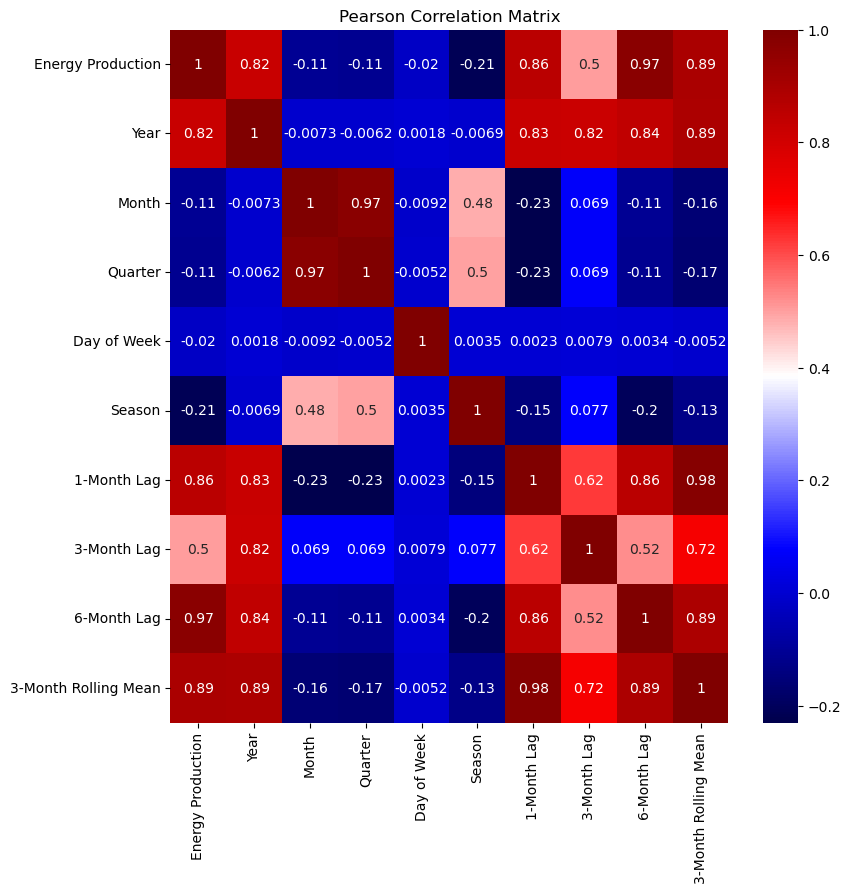

In [80]:
corr_matrix = df_cleaned.corr(method='pearson')

plt.figure(figsize=(9,9))
sns.heatmap(corr_matrix, annot=True, cmap='seismic')
plt.title('Pearson Correlation Matrix')
plt.show()

# Now that we've engineered new features and added dimensionality to the date frame, we can generate a new correlation matrix.
# Upon reviewing the correlation coefficients, we can establish that Year and Energy Production are highly correlated.
# Unsurprisingly, Month and Quarter are highly correlated as the calendar month dictates the calendar quarter.
# The Energy Production and Year features are highly correlated to the lag and rolling time frame features. This is likely an indication of multicollinearity amongst the lag and rolling time frame features.
# We will address the multicollinearity by using Ridge Regression, which applies penalties to feature coefficients.

In [81]:
# 3 -- REGRESSION MODEL: DEVELOPMENT & EVALUATION

In [82]:
X = df_cleaned.iloc[:, 1:]
y = df_cleaned['Energy Production']

# Before building and training our regression models, we must first define our target variable and features.
# Our target variable is Energy Production and our features are Year, Month, Quarter, Day of Week, Season, 1-Month Lag, 3-Month Lag, 6-Month Lag, and 3-Month Rolling Mean.

In [83]:
X_train, X_interim, y_train, y_interim = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)

X_val, X_test, y_val, y_test = train_test_split(X_interim, y_interim, test_size=0.5, random_state=42, shuffle=False)


# In order to split our data set in a 70% training subset, 15% validation subset, and 15% test subset, we perform two splits.
# The first split involves dividing the data set into a 70% training subset and 30% interim subset that we will split further.
# The 30% interim subset is split in half to form a 15% validation subset and 15% test subset.
# The shuffle parameter is set to 'False' so that the time series data is not shuffled. For the purpose of our regression models, we want to preserve the sequential/chronological order of the data.
# The random_state parameter is set to a random number ('42') in order to ensure that the generated data subsets are reproducible.

In [84]:
# LINEAR REGRESSION

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

linear = LinearRegression()
linear.fit(X_train, y_train)

# We implement Linear Regression to develop our first model.
# The model is then fitted (or trained) using the 70% training subset.

LinearRegression()

In [86]:
y_test_pred = linear.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"Test Subset MSE: {mse_test:.4f}")
print(f"Test Subset R2: {r2_test:.4f}")
print(f"Test MAE: {mae_test:.3f}")


# The 15% test subset is used to evaluate the performance of the Linear Regression model.
# We assign the Energy Production predictions for the test subset to 'y_test_pred'.
# The mean squared error (MSE), mean absolute error (MAE), and R-squared/Coefficient of Determination (R2) metrics are then used to measure the predictive performance.
# The R2 measurement implies that the model is able to explain 71% of the Energy Production variance when making predictions on the test subset. 
# The mean squared error of 0.1293 is low, which suggests that the difference between actual and predicted Energy Production values is low. Thus, the model displays significant accuracy in making predictions on the test subset.
# The mean absolute error is measured at less than 10%, which further illustrates the predictive accuracy of the model.

Test Subset MSE: 0.1293
Test Subset R2: 0.7103
Test MAE: 0.301


In [87]:
# LINEAR REGRESSION -- RIDGE

In [88]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
param_grid = {'alpha': [0.1, 1, 10, 100, 1000]}

grid_search = GridSearchCV(Ridge(), param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)

# Ridge Regressor is imported into our linear model in order to address the multicollinearity that was evidenced by the correlation matrix we generated.
# Ridge Regression functions by applying penalties to feature coefficients. 
# The 'alpha' parameter relates to the penalty that applied to feature coefficients. A larger alpha value will reduce the feature coefficieints and reduce multicollinearity within the model.
# In order to find the optimal setting for alpha, we create a parameter grid and use GridSearchCV for hyperpatameter tuning.
# GridSearchCV is fitted (or trained) using the training subset, and the optimal hyperparameter setting is evaluated using the negative mean squared error.


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.1, 1, 10, 100, 1000]},
             scoring='neg_mean_squared_error')

In [89]:
optimal_param = grid_search.best_params_
print(optimal_param)

# The optimal hyerparameter for Ridge Regressor is alpha set to 0.1.

{'alpha': 0.1}


In [90]:
ridge = Ridge(alpha= 0.1)
ridge.fit(X_train, y_train)

# We can now train the Ridge Regressor model using the optimal hyperparameter setting.

Ridge(alpha=0.1)

In [91]:
feature_importances = pd.DataFrame({'Feature': X_train.columns,'Feature Coefficient': ridge.coef_})
feature_importances['Absolute Value of Coefficient'] = feature_importances['Feature Coefficient'].abs()

feature_importances.head(10)

# Once the Ridge Regressor model has been trained, we can use the  feature coefficients to illustrate the importance of each feature in the model's predictions.
# Using 'ridge.coef_', we obtain the feature coefficients and create a data frame using the coefficient values. We calculate the absolute values of the feature coefficients and add them to the data frame within a supplementary column.

,Feature,Feature Coefficient,Absolute Value of Coefficient
0,Year,0.031589,0.031589
1,Month,-0.017126,0.017126
2,Quarter,0.068546,0.068546
3,Day of Week,-0.008465,0.008465
4,Season,-0.036015,0.036015
5,1-Month Lag,-0.686998,0.686998
6,3-Month Lag,-0.346646,0.346646
7,6-Month Lag,0.551028,0.551028
8,3-Month Rolling Mean,1.129194,1.129194


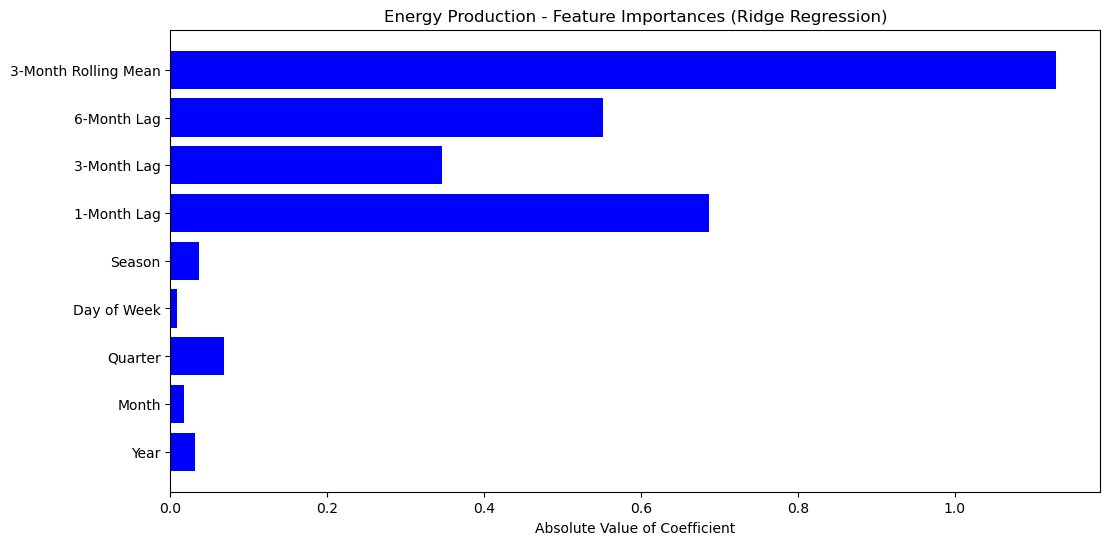

In [92]:
plt.figure(figsize=(12, 6))
plt.barh(feature_importances['Feature'], feature_importances['Absolute Value of Coefficient'], color='blue')
plt.xlabel('Absolute Value of Coefficient')
plt.title('Energy Production - Feature Importances (Ridge Regression)')
plt.show()

# In order to better illustrate the magnitudes of the various feature coefficients, we create a bar plot.
# The 3-Month Rolling Mean feature has the highest absolute coefficient value. Thus, it is the most important feature when the Ridge Regressor model makes predictions.

In [93]:
y_val_pred = ridge.predict(X_val)


mse_val = mean_squared_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print(f"Validation Subset MSE: {mse_val:.4f}")
print(f"Validation Subset R2: {r2_val:.4f}")
print(f"Validation MAE: {mae_val:.3f}")

# Once the Ridge Regressor model has been trained, we use it to make energy production predictions on the validation subset. 
# We assign the Energy Production predictions for the validation subset to 'y_val_pred'.
# The mean squared error (MSE), mean absolute error (MAE), and R-squared/Coefficient of Determination (R2) metrics are then used to measure the predictive performance.
# The R2 measurement implies that the model is able to explain about 82% of the Energy Production variance when making predictions on the validation subset. This is 11 percentage points higher than the R2 measurement for the test subset using our original linear regression model.
# The mean squared error of 0.0725 is very low, even lower than the MSE measured using of our original linear regression model. This suggests that the difference between actual and predicted Energy Production values is very low. Therefore, the optimized Ridge Regressor model has a high degree of predictive accuracy.
# The mean absolute error is measured at less 10 and close to zero, which suggests a high degree of predictive accuracy.

Validation Subset MSE: 0.0725
Validation Subset R2: 0.8206
Validation MAE: 0.231


In [94]:
# RANDOM FOREST REGRESSOR

In [98]:
from sklearn.ensemble import RandomForestRegressor

ran_reg = RandomForestRegressor(random_state=42)
ran_reg.fit(X_train, y_train)

# We will now build another regression model using the Random Forest Regressor and evaluate its predictive performance.
# Its evaluation metrics will be compared to that of the linear and Ridge regressor models we developed.

RandomForestRegressor(random_state=42)

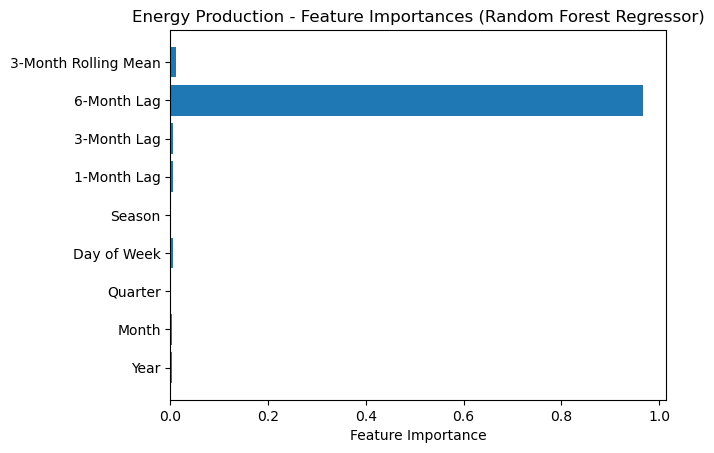

In [99]:
importantfeatures = ran_reg.feature_importances_

plt.barh(X.columns, importantfeatures)
plt.xlabel('Feature Importance')
plt.title('Energy Production - Feature Importances (Random Forest Regressor)')
plt.show()

# Once the model has been fitted to the training subset, we generate the feature importance values using 'ran_reg.feature_importances_' and construct a bar plot to illustrate the most important feature.
# For the Random Forest Regressor model, the most important feature in its predidctions is the 6-Month Lag feature.

In [101]:
y_test_pred = ran_reg.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"Test Subset MSE: {mse_test:.4f}")
print(f"Test Subset R2: {r2_test:.4f}")
print(f"Test MAE: {mae_test:.3f}")

# The 15% test subset is now used to evaluate the performance of the Random Forest Regression model.
# As in the= case of the previous models, we assign the Energy Production predictions for the test subset to 'y_test_pred'.
# The mean squared error (MSE), mean absolute error (MAE), and R-squared/Coefficient of Determination (R2) metrics are then used to measure the predictive performance.
# The R2 measurement suggests that the Random Forest Regressor model is able to explain roughly 75% of the Energy Production variance when making predictions on the test subset. 
# The mean squared error of 0.1133 is low, indicating that the difference between actual and predicted Energy Production values is also low. 
# The mean absolute error is also close to zero, which provides further evidence for the high predictive accuracy of the model.


Test Subset MSE: 0.1133
Test Subset R2: 0.7461
Test MAE: 0.240


In [102]:
# RANDOM FOREST REGRESSOR (OPTIMIZED)

In [110]:
param_grid = {'n_estimators': [100,200,300],
             'max_depth': [10,20,30]}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)



# Because the Random Forest Regressor operates using fitting a forest of decision trees to training data, we can optimize our model using the 'n_estimators' and 'max_depth' parameters.
# The n_estimators parameter determines the number of trees that will comprise our random forest.
# The max_depth parameter dictates the maximum number of layers a tree can have.
# In order to find the optimal setting for alpha, we create a parameter grid for 'n_estimators' and 'max_depth', and then we use GridSearchCV for hyperpatameter tuning.
# GridSearchCV is re-fitted to the training subset, and the optimal hyperparameter setting combination is evaluated using the negative mean squared error.

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [10, 20, 30],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error')

In [111]:
grid_search.best_params_

# The optimal hyerparameter for the Random Forest Regressor is a max_depth of '30' and m_estimators set to the default value of '100'.

{'max_depth': 10, 'n_estimators': 100}

In [112]:
ran_reg = RandomForestRegressor(max_depth=10, n_estimators=100)
ran_reg.fit(X_train, y_train)

# We are now able train the Random Forest Regressor using the optimal hyperparameter setting.

RandomForestRegressor(max_depth=10)

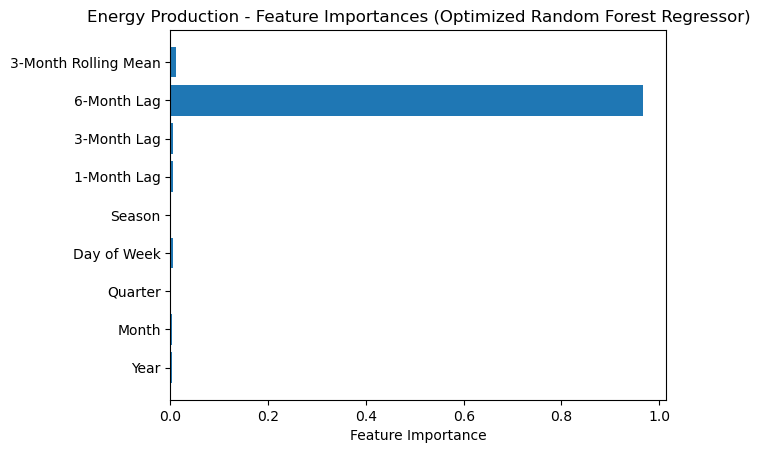

In [113]:
importantfeatures = ran_reg.feature_importances_

plt.barh(X.columns, importantfeatures)
plt.xlabel('Feature Importance')
plt.title('Energy Production - Feature Importances (Optimized Random Forest Regressor)')
plt.show()


# After training the optimized Random Forest Regressor, we can generate the feature importance values and plot them for the purpose of comparison.
# As was the case for the original Random Forest Regressor model, the most important feature in making predidctions is the 6-Month Lag feature.

In [114]:
y_val_pred = ran_reg.predict(X_val)
mse_val = mean_squared_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print(f"Validation Subset MSE: {mse_val:.4f}")
print(f"Validation Subset R2: {r2_val:.4f}")
print(f"Validation MAE: {mae_val:.3f}")

# Once the optimized Random Forest Regressor model has been trained, we use it to make energy production predictions on the validation subset. 
# We assign the Energy Production predictions for the validation subset to 'y_val_pred'.
# The mean squared error (MSE), mean absolute error (MAE), and R-squared/Coefficient of Determination (R2) serve as our evaluation metrics for the model's predictive performance.
# The R2 measurement implies that the model is able to explain about 79% of the Energy Production variance when making predictions on the validation subset. This is slightly lower than the validation R2 measurement for the optimized Ridge Regressor model.
# The mean squared error of 0.0847 is very low, but is slightly higher than that of the Ridge Regressor model.  Nevertheless, this model has a high degree of predictive accuracy.
# Additionally, the mean absolute error is close to zero, which also suggests a high degree of predictive accuracy.

Validation Subset MSE: 0.0843
Validation Subset R2: 0.7915
Validation MAE: 0.240


In [115]:
# FINDINGS

# The Ridge Regressor model has a lower MSE value than the optimized Random Forest Regressor model, signifying a greater ability to reduce reduce errors and generate more accurate predictions.
# Furthermore, the Ridge Regressor has a lower MAE value than the Random Forest Regressor, adding evidence to its accuracy in predicting.
# Moreover, the Ridge Regressor has the highest R2 (coefficient of determination) value of the models that were evaluated. This means that it is the most effective in explaining the variance in target variable, energy production, and detecting patterns within the data set that inform the energy production's value.
# A key distinction is that the Ridge Regressor model deems the 3-Month Rolling Mean to be the most important feature, whereas the optimized Random Forest Regressor model points to the 6-Month Lag feature as the most important. 

In [116]:
# 4 -- CONCLUSIONS & RECOMMENDATIONS

# The Ridge Regressor model is the most effective at making accurate energy production predictions, and it determined that the 3-Month Rolling Mean is the most important feature for making predictions.
# Since the 3-Month Rolling Mean was measured as the most important feature, businesses in the energy industry could focus in on energy production trends over the last few calendar months when anticipating demand.
# Because of the efficacy of the Ridge Regressor model we've built and evaluated, businesses in the energy industry could implement similar models as a functional component within their operations.
# The high degree of predictive accuracy displayed by the model would enable businesses to forecast near future energy production. As a result of this capability, businesses could offer dynamic pricing to leverage anticipated drops or surges in energy demands.